In [119]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [120]:
data_path = "2021-10-FWQ7DT_Martin_data.csv"
description_path = "2021-12_FWQ7DT_Martin_Data-Description.xlsx"

df = pd.read_csv(
    data_path,
    encoding="latin1",
    low_memory=False
)

print(df.shape)
df.head()

(133164, 178)


,entry_id,article_id,sample,analysis,latitude,longitude,sample_description,mag_det,material_analyzed,citation,method,age_method,comments,depth,country,craton,orogen,terrane,basin,region,lithology,suite_pluton_name,strat_unit,pb206_u238_age_2sd,pb206_u238_age_ma,pb207_pb206_age_2sd,pb207_pb206_age_ma,pb207_u235_age_2sd,pb207_u235_age_ma,pb208_th232_age_2sd,pb208_th232_age_ma,age,age_2sd,hf176_hf177,hf176_hf177_2sd,hf178_hf177,hf178_hf177_2sd,hf180_hf177,hf180_hf177_2sd,lu176_hf177,lu176_hf177_2sd,yb176_hf177,yb176_hf177_2sd,nd143_nd144,nd143_nd144_2sd,pb206_u238,pb206_u238_2sd,pb207_pb206,pb207_pb206_2sd,pb207_u235,pb207_u235_2sd,pb208_th232,pb208_th232_2sd,ag_ppm,al_ppm,as_ppm,au_ppm,b_ppm,ba_ppm,be_ppm,bi_ppm,br_ppm,c_ppm,ca_ppm,cd_ppm,ce_ppm,cl_ppm,co_ppm,cr_ppm,cs_ppm,cu_ppm,dy_ppm,er_ppm,eu_ppm,f_ppm,fe_ppm,ga_ppm,gd_ppm,ge_ppm,h_ppm,hf_ppm,hg_ppm,ho_ppm,i_ppm,in_ppm,ir_ppm,k_ppm,la_ppm,li_ppm,lu_ppm,mg_ppm,mn_ppm,mo_ppm,n_ppm,na_ppm,nb_ppm,nd_ppm,ni_ppm,os_ppm,p_ppm,pa_ppm,pb_ppm,pd_ppm,pm_ppm,pr_ppm,pt_ppm,rb_ppm,re_ppm,rh_ppm,ru_ppm,s_ppm,sb_ppm,sc_ppm,se_ppm,si_ppm,sm_ppm,sn_ppm,sr_ppm,ta_ppm,tb_ppm,te_ppm,th_ppm,ti_ppm,tl_ppm,tm_ppm,u_ppm,v_ppm,w_ppm,y_ppm,yb_ppm,zn_ppm,zr_ppm,continent,pb206_pb207,pb206_pb207_2sd,pb206_207Pb_ma,pb206_207Pb_ma_2sd,pbc_206_pc,do18m,do18m_2sd,do18n,do19n_2sd,pb206_pb204,pb206_pb204_2sd,pb207_pb204,pb207_pb204_2sd,pb208_pb204,pb208_pb204_2sd,rb87_sr86,rb87_sr86_2sd,rb87_sr87,rb87_sr87_2sd,th232_pb204,th232_pb204_2sd,th232_u238,th232_u238_2sd,u238_pb204,u238_pb204_2sd,u238_pb206,u238_pb206_2sd,rho_207pb235u_206pb238u,rho_206pb238u_207pb235u,u238_th232,u238_th232_2sd,pb208_pb206,o16_o18,o18_o16,o18_o16_2sd,u238_pb206_age_ma,u238_pb206_age_2sd,rho_238u206pb_207pb206pb,th_u,elevation,facies,yb176_lu176_hf176pc,volts_hf,do18n_2sd,doi
0,1,1132661,BLT01,3.1,NaN,NaN,NaN,magmatic,zircon,Zircon ages and Hf isotopic compositions of pl...,SHRIMP,NaN,common Pb corrected ratios and ages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gabbro,NaN,NaN,33.0,435.0,763.0,763.0,143,492.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0698,0.0054,0.0647,0.0209,0.623,0.213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.6084/m9.figshare.1132661.v1
1,2,1132661,BLT01,10.1,NaN,NaN,NaN,magmatic,zircon,Zircon ages and Hf isotopic compositions of pl...,SHRIMP,NaN,common Pb corrected ratios and ages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gabbro,NaN,NaN,30.0,455.0,102.0,629.0,34,485.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0731,0.0049,0.0607,0.0028,0.612,0.053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132,NaN,NaN,NaN,227.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.6084/m9.figshare.1132661.v1
2,3,1132661,BLT01,9.1,NaN,NaN,NaN,magmatic,zircon,Zircon ages and Hf isotopic compositions of pl...,SHRIMP,NaN,common Pb corrected ratios and ages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gabbro,NaN,NaN,12.0,441.0,91.0,614.0,20,470.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0709,0.0020,0.0603,0.0025,0.589,0.031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [121]:
pd.set_option("display.max_columns", None)

df.columns.tolist()

['entry_id',
 'article_id',
 'sample',
 'analysis',
 'latitude',
 'longitude',
 'sample_description',
 'mag_det',
 'material_analyzed',
 'citation',
 'method',
 'age_method',
 'comments',
 'depth',
 'country',
 'craton',
 'orogen',
 'terrane',
 'basin',
 'region',
 'lithology',
 'suite_pluton_name',
 'strat_unit',
 'pb206_u238_age_2sd',
 'pb206_u238_age_ma',
 'pb207_pb206_age_2sd',
 'pb207_pb206_age_ma',
 'pb207_u235_age_2sd',
 'pb207_u235_age_ma',
 'pb208_th232_age_2sd',
 'pb208_th232_age_ma',
 'age',
 'age_2sd',
 'hf176_hf177',
 'hf176_hf177_2sd',
 'hf178_hf177',
 'hf178_hf177_2sd',
 'hf180_hf177',
 'hf180_hf177_2sd',
 'lu176_hf177',
 'lu176_hf177_2sd',
 'yb176_hf177',
 'yb176_hf177_2sd',
 'nd143_nd144',
 'nd143_nd144_2sd',
 'pb206_u238',
 'pb206_u238_2sd',
 'pb207_pb206',
 'pb207_pb206_2sd',
 'pb207_u235',
 'pb207_u235_2sd',
 'pb208_th232',
 'pb208_th232_2sd',
 'ag_ppm',
 'al_ppm',
 'as_ppm',
 'au_ppm',
 'b_ppm',
 'ba_ppm',
 'be_ppm',
 'bi_ppm',
 'br_ppm',
 'c_ppm',
 'ca_ppm',
 'cd_

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133164 entries, 0 to 133163
Columns: 178 entries, entry_id to doi
dtypes: float64(141), int64(2), object(35)
memory usage: 180.8+ MB


In [123]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing.head(40)

nd143_nd144_2sd    100.0
nd143_nd144        100.0
facies             100.0
sn_ppm             100.0
te_ppm             100.0
tl_ppm             100.0
v_ppm              100.0
w_ppm              100.0
do19n_2sd          100.0
u238_pb204         100.0
u238_pb204_2sd     100.0
th232_pb204_2sd    100.0
rb87_sr87_2sd      100.0
th232_pb204        100.0
rb87_sr87          100.0
rb87_sr86_2sd      100.0
rb87_sr86          100.0
pb208_pb204_2sd    100.0
i_ppm              100.0
in_ppm             100.0
ir_ppm             100.0
mg_ppm             100.0
ni_ppm             100.0
n_ppm              100.0
mn_ppm             100.0
se_ppm             100.0
re_ppm             100.0
rh_ppm             100.0
ru_ppm             100.0
pt_ppm             100.0
pd_ppm             100.0
pm_ppm             100.0
pa_ppm             100.0
os_ppm             100.0
s_ppm              100.0
cl_ppm             100.0
cr_ppm             100.0
co_ppm             100.0
ge_ppm             100.0
h_ppm              100.0


In [124]:
missing = df.isna().mean().sort_values(ascending=False) * 100

# colunas com MENOS dados faltantes
missing.tail(60)


hf178_hf177_2sd            93.841429
rho_206pb238u_207pb235u    93.740050
pr_ppm                     93.635667
tb_ppm                     93.483224
tm_ppm                     93.480971
ho_ppm                     93.352558
lu_ppm                     93.266949
nd_ppm                     92.742032
eu_ppm                     92.679703
ce_ppm                     92.654922
gd_ppm                     92.594095
er_ppm                     92.588838
sm_ppm                     92.573819
dy_ppm                     92.540777
yb_ppm                     92.395843
hf178_hf177                91.457151
pbc_206_pc                 90.001802
yb176_hf177_2sd            88.894897
age_2sd                    87.710643
yb176_hf177                84.458262
lu176_hf177_2sd            83.955123
sample_description         83.550359
terrane                    83.273257
pb_ppm                     81.493497
pb206_pb204                78.503199
country                    77.875402
age                        77.068877
h

In [125]:
good_cols = missing[missing < 50].index.tolist()

print(len(good_cols))
good_cols


21


['u_ppm',
 'pb207_pb206',
 'pb207_pb206_2sd',
 'pb207_u235',
 'pb207_u235_age_ma',
 'pb207_u235_2sd',
 'pb206_u238_2sd',
 'pb207_u235_age_2sd',
 'pb206_u238',
 'pb207_pb206_age_ma',
 'pb207_pb206_age_2sd',
 'pb206_u238_age_2sd',
 'pb206_u238_age_ma',
 'analysis',
 'sample',
 'doi',
 'article_id',
 'material_analyzed',
 'citation',
 'mag_det',
 'entry_id']

In [126]:
# Coluna alvo principal
target_age_col = "pb206_u238_age_ma"

# Colunas geoquimicas candidatas, sem usar razoes U-Pb como entrada
geo_candidate_cols = [
    "u_ppm", "th_ppm",
    "hf176_hf177", "hf178_hf177",
    "lu176_hf177", "yb176_hf177",
    "la_ppm", "ce_ppm", "pr_ppm", "nd_ppm", "sm_ppm",
    "eu_ppm", "gd_ppm", "tb_ppm", "dy_ppm", "ho_ppm",
    "er_ppm", "tm_ppm", "yb_ppm", "lu_ppm",
    "hf_ppm", "ti_ppm", "y_ppm", "nb_ppm", "ta_ppm"
]

# Ficar só com colunas que realmente existem no dataframe
geo_candidate_cols = [col for col in geo_candidate_cols if col in df.columns]

print("Colunas geoquímicas encontradas:")
print(geo_candidate_cols)

# Linhas com idade conhecida
df_age = df.dropna(subset=[target_age_col]).copy()

print("Linhas com idade:", df_age.shape[0])

# Ver preenchimento das geoquímicas dentro das linhas com idade
geo_missing_age_subset = df_age[geo_candidate_cols].isna().mean().sort_values() * 100
geo_missing_age_subset

Colunas geoquímicas encontradas:
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm', 'nb_ppm', 'ta_ppm']
Linhas com idade: 94214


u_ppm          29.780075
th_ppm         45.807417
hf176_hf177    89.891099
lu176_hf177    89.891099
yb176_hf177    91.386630
yb_ppm         95.766022
dy_ppm         95.774513
ce_ppm         95.802110
sm_ppm         95.810601
eu_ppm         95.829707
er_ppm         95.842444
gd_ppm         95.846689
nd_ppm         95.915681
la_ppm         96.303097
hf178_hf177    96.321141
ti_ppm         96.430467
hf_ppm         96.470801
y_ppm          96.832742
lu_ppm         96.864585
ho_ppm         96.921901
tm_ppm         96.969665
tb_ppm         96.970726
pr_ppm         97.117201
nb_ppm         98.245484
ta_ppm         98.497039
dtype: float64

In [127]:
# Quantidade de variaveis geoquimicas preenchidas por linha
df_age["n_geo_features"] = df_age[geo_candidate_cols].notna().sum(axis=1)

df_age["n_geo_features"].value_counts().sort_index()

n_geo_features
0     26115
1     12514
2     42961
3      1362
4       736
5      5628
6       927
7         1
8         1
10       14
11       40
12        9
13       31
14     1131
15      229
16       90
17       71
18      601
19      184
20      485
21      724
22      120
23        4
24      215
25       21
Name: count, dtype: int64

In [128]:
for n in [1, 2, 3, 5, 8, 10]:
    count = (df_age["n_geo_features"] >= n).sum()
    print(f"Linhas com pelo menos {n} variáveis geoquímicas: {count}")

Linhas com pelo menos 1 variáveis geoquímicas: 68099
Linhas com pelo menos 2 variáveis geoquímicas: 55585
Linhas com pelo menos 3 variáveis geoquímicas: 12624
Linhas com pelo menos 5 variáveis geoquímicas: 10526
Linhas com pelo menos 8 variáveis geoquímicas: 3970
Linhas com pelo menos 10 variáveis geoquímicas: 3969


In [129]:
# Escolher subconjunto com dados geoquimicos suficientes
min_geo_features = 5

model_df = df_age[df_age["n_geo_features"] >= min_geo_features].copy()

print("Linhas no dataset de ML:", model_df.shape[0])
print("Colunas:", model_df.shape[1])

Linhas no dataset de ML: 10526
Colunas: 179


In [130]:
def classify_age(age):
    if pd.isna(age):
        return np.nan
    elif age < 250:
        return "0-250 Ma"
    elif age < 541:
        return "250-541 Ma"
    elif age < 1000:
        return "541-1000 Ma"
    elif age < 1600:
        return "1000-1600 Ma"
    elif age < 2500:
        return "1600-2500 Ma"
    else:
        return ">2500 Ma"

model_df["age_class"] = model_df[target_age_col].apply(classify_age)

model_df["age_class"].value_counts()

age_class
0-250 Ma        3063
541-1000 Ma     2371
250-541 Ma      1755
1600-2500 Ma    1286
1000-1600 Ma    1153
>2500 Ma         898
Name: count, dtype: int64

In [131]:
for col in geo_candidate_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


# Evitar divisoes por zero
model_df["th_u_ratio"] = np.where(
    model_df["u_ppm"] > 0,
    model_df["th_ppm"] / model_df["u_ppm"],
    np.nan
)

if "ce_ppm" in model_df.columns and "yb_ppm" in model_df.columns:
    model_df["ce_yb_ratio"] = np.where(
        model_df["yb_ppm"] > 0,
        model_df["ce_ppm"] / model_df["yb_ppm"],
        np.nan
    )

if "nb_ppm" in model_df.columns and "ta_ppm" in model_df.columns:
    model_df["nb_ta_ratio"] = np.where(
        model_df["ta_ppm"] > 0,
        model_df["nb_ppm"] / model_df["ta_ppm"],
        np.nan
    )

if "lu_ppm" in model_df.columns and "hf_ppm" in model_df.columns:
    model_df["lu_hf_ratio"] = np.where(
        model_df["hf_ppm"] > 0,
        model_df["lu_ppm"] / model_df["hf_ppm"],
        np.nan
    )

feature_cols = geo_candidate_cols + [
    "th_u_ratio",
    "ce_yb_ratio",
    "nb_ta_ratio",
    "lu_hf_ratio"
]

feature_cols = [col for col in feature_cols if col in model_df.columns]

# Remover features muito vazias dentro do subconjunto
feature_missing = model_df[feature_cols].isna().mean() * 100
feature_cols = feature_missing[feature_missing < 80].index.tolist()

print("Features finais:", len(feature_cols))
print(feature_cols)

X = model_df[feature_cols].copy()
y = model_df["age_class"].copy()


Features finais: 26
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm', 'th_u_ratio', 'ce_yb_ratio', 'lu_hf_ratio']


In [132]:
y.value_counts(normalize=True) * 100

age_class
0-250 Ma        29.099373
541-1000 Ma     22.525176
250-541 Ma      16.673000
1600-2500 Ma    12.217367
1000-1600 Ma    10.953829
>2500 Ma         8.531256
Name: proportion, dtype: float64

In [133]:
# Imports usados na modelagem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedShuffleSplit,
    ShuffleSplit,
    GroupKFold,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42

In [134]:
# Definicao das features: somente geoquimica

# Manter a lista definida anteriormente no notebook.
# Features isotópicas usadas diretamente para calcular idades
# U-Pb/Th-Pb nao sao adicionadas aqui

feature_cols = [col for col in feature_cols if col in model_df.columns]

# Garantir que as features sejam numéricas
for col in feature_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Remover features extremamente vazias no subconjunto modelado
missing_pct = model_df[feature_cols].isna().mean() * 100
feature_cols = missing_pct[missing_pct < 80].index.tolist()

X = model_df[feature_cols].copy()
y_cls = model_df["age_class"].copy()

print(f"Features finais: {len(feature_cols)}")
print(feature_cols)
print(f"Amostras para classificação: {len(model_df):,}")


Features finais: 26
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm', 'th_u_ratio', 'ce_yb_ratio', 'lu_hf_ratio']
Amostras para classificação: 10,526


In [135]:
# Definir grupos para evitar vazamento entre treino e teste

# O codigo procura identificadores comuns. Se o dataset não possuir
# nenhum deles, usar um split aleatório explícito e dar frag

group_candidates = [
    "sample", "sample_id", "Sample", "sampleID",
    "article_id", "article", "paper_id",
    "reference_id", "reference"
]

group_col = next((c for c in group_candidates if c in model_df.columns), None)

if group_col is not None:
    groups = model_df[group_col].astype("string").fillna("__missing_group__")
    print(f"Split agrupado por: {group_col}")
    print(f"Grupos únicos: {groups.nunique():,}")
else:
    groups = None
    print("AVISO: nenhum identificador de grupo foi encontrado.")
    print("O notebook fará split por linha, mas o resultado deve ser interpretado com cautela.")


Split agrupado por: sample
Grupos únicos: 374


In [136]:
# Train/test split da classificacao

if groups is not None:
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
    train_idx, test_idx = next(splitter.split(X, y_cls, groups=groups))
else:
    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
    train_idx, test_idx = next(splitter.split(X, y_cls))

X_train_cls = X.iloc[train_idx].copy()
X_test_cls = X.iloc[test_idx].copy()
y_train_cls = y_cls.iloc[train_idx].copy()
y_test_cls = y_cls.iloc[test_idx].copy()

print(f"Treino: {len(X_train_cls):,}")
print(f"Teste:  {len(X_test_cls):,}")


Treino: 8,584
Teste:  1,942


In [137]:
# Random Forest para classificacao

classifier = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

classifier.fit(X_train_cls, y_train_cls)
y_pred_cls = classifier.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_cls, y_pred_cls))
print("Macro F1:", f1_score(y_test_cls, y_pred_cls, average="macro"))
print()
print(classification_report(y_test_cls, y_pred_cls))


Accuracy: 0.7286302780638517
Balanced Accuracy: 0.6793781127389008
Macro F1: 0.6881023757241175

              precision    recall  f1-score   support

    0-250 Ma       0.82      0.92      0.87       623
1000-1600 Ma       0.55      0.32      0.41       164
1600-2500 Ma       0.71      0.79      0.75       223
  250-541 Ma       0.65      0.57      0.61       374
 541-1000 Ma       0.65      0.69      0.67       422
    >2500 Ma       0.88      0.77      0.82       136

    accuracy                           0.73      1942
   macro avg       0.71      0.68      0.69      1942
weighted avg       0.72      0.73      0.72      1942



In [138]:
def training(X_train, y_train, param_dist=None):
    print("Começando treinamento...")

    if param_dist is None:
        param_dist = {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 15, 20, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }

    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=10,
        scoring="neg_mean_absolute_error",
        cv=3,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train)

    print("Melhores parâmetros:")
    print(search.best_params_)

    return search

In [139]:
df.columns = df.columns.str.strip()
df["Age_numeric"] = df["age"]

# Remove linhas sem idade
df_model = df.dropna(subset=["Age_numeric"]).copy()

# Pega só colunas numéricas
X = df_model.select_dtypes(include=["number"]).copy()

# Remove a idade e colunas que vazam diretamente a resposta
cols_to_remove = [
    "age",
    "age_2sd",
    "Age_numeric",
    "pb206_u238_age_ma",
    "pb207_pb206_age_ma",
    "pb207_u235_age_ma",
    "pb208_th232_age_ma",
    "u238_pb206_age_ma",
    "pb206_207Pb_ma"
]

X = X.drop(columns=[col for col in cols_to_remove if col in X.columns])
y = df_model["Age_numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [140]:
# Matriz de confusao - classificacao
labels = classifier.named_steps["classifier"].classes_
cm = confusion_matrix(y_test_cls, y_pred_cls, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real: {x}" for x in labels],
    columns=[f"Previsto: {x}" for x in labels]
)

cm_df


,Previsto: 0-250 Ma,Previsto: 1000-1600 Ma,Previsto: 1600-2500 Ma,Previsto: 250-541 Ma,Previsto: 541-1000 Ma,Previsto: >2500 Ma
Real: 0-250 Ma,572,2,1,36,12,0
Real: 1000-1600 Ma,5,53,23,6,77,0
Real: 1600-2500 Ma,7,9,177,12,5,13
Real: 250-541 Ma,75,13,9,215,61,1
Real: 541-1000 Ma,33,20,16,60,293,0
Real: >2500 Ma,2,0,23,3,3,105


In [141]:
# Permutation importance da classificacao

perm_cls = permutation_importance(
    classifier,
    X_test_cls,
    y_test_cls,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="f1_macro"
)

importance_cls = (
    pd.DataFrame({
        "feature": X_test_cls.columns,
        "importance_mean": perm_cls.importances_mean,
        "importance_std": perm_cls.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_cls.head(20)


,feature,importance_mean,importance_std
0,hf176_hf177,0.316055,0.004441
1,yb176_hf177,0.042568,0.005508
2,th_u_ratio,0.034782,0.003563
3,u_ppm,0.027252,0.005025
4,th_ppm,0.024153,0.004730
5,lu176_hf177,0.014932,0.004101
6,hf178_hf177,0.010724,0.003327
7,ti_ppm,0.009429,0.002284
8,ce_ppm,0.009166,0.002575
9,yb_ppm,0.006432,0.001976


In [142]:
# Dataset da regressao

regression_target = "age" if "age" in df.columns else target_age_col

df_reg = df.copy()
df_reg.columns = df_reg.columns.str.strip()
df_reg[regression_target] = pd.to_numeric(
    df_reg[regression_target],
    errors="coerce"
)

# Somente features geoquímicas explicitamente autorizadas
reg_feature_cols = [c for c in feature_cols if c in df_reg.columns]

reg_data = df_reg.dropna(subset=[regression_target]).copy()
X_reg = reg_data[reg_feature_cols].apply(pd.to_numeric, errors="coerce")
y_reg = reg_data[regression_target].astype(float)

# Pelo menos uma feature precisa estar disponível
valid_rows = X_reg.notna().any(axis=1)
X_reg = X_reg.loc[valid_rows].copy()
y_reg = y_reg.loc[valid_rows].copy()
reg_data = reg_data.loc[valid_rows].copy()

print(f"Alvo da regressão: {regression_target}")
print(f"Features usadas: {len(reg_feature_cols)}")
print(f"Amostras: {len(X_reg):,}")
print(reg_feature_cols)


Alvo da regressão: age
Features usadas: 23
Amostras: 29,483
['u_ppm', 'th_ppm', 'hf176_hf177', 'hf178_hf177', 'lu176_hf177', 'yb176_hf177', 'la_ppm', 'ce_ppm', 'pr_ppm', 'nd_ppm', 'sm_ppm', 'eu_ppm', 'gd_ppm', 'tb_ppm', 'dy_ppm', 'ho_ppm', 'er_ppm', 'tm_ppm', 'yb_ppm', 'lu_ppm', 'hf_ppm', 'ti_ppm', 'y_ppm']


In [143]:
# Verificação explicita de leakage
# ------------------------------------------------------------
# Qualquer coluna de idade ou razao radiometrica de datacao que
# exista no dataframe NAO pode fazer parte das features.

forbidden_tokens = [
    "age", "pb206", "pb207", "pb208", "u238", "u235", "th232"
]

leakage_candidates = [
    c for c in reg_feature_cols
    if any(token in c.lower() for token in forbidden_tokens)
]

if leakage_candidates:
    raise ValueError(
        "Possível leakage nas features: " + ", ".join(leakage_candidates)
    )

print("Verificação de leakage: OK")


Verificação de leakage: OK


In [144]:
# Grupos da regressao

reg_group_col = next(
    (c for c in group_candidates if c in reg_data.columns),
    None
)

if reg_group_col is not None:
    reg_groups = (
        reg_data[reg_group_col]
        .astype("string")
        .fillna("__missing_group__")
    )
    print(f"Split agrupado por: {reg_group_col}")
else:
    reg_groups = None
    print("AVISO: nenhum identificador de grupo foi encontrado para a regressão.")

if reg_groups is not None:
    splitter_reg = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
    train_idx_reg, test_idx_reg = next(
        splitter_reg.split(X_reg, y_reg, groups=reg_groups)
    )
else:
    splitter_reg = ShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
    train_idx_reg, test_idx_reg = next(
        splitter_reg.split(X_reg, y_reg)
    )

X_train_reg = X_reg.iloc[train_idx_reg].copy()
X_test_reg = X_reg.iloc[test_idx_reg].copy()
y_train_reg = y_reg.iloc[train_idx_reg].copy()
y_test_reg = y_reg.iloc[test_idx_reg].copy()

print(f"Treino: {len(X_train_reg):,}")
print(f"Teste:  {len(X_test_reg):,}")


Split agrupado por: sample
Treino: 23,672
Teste:  5,811


In [145]:
# Baseline da regressão

from sklearn.metrics import root_mean_squared_error

baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", DummyRegressor(strategy="median"))
])

baseline.fit(X_train_reg, y_train_reg)
baseline_pred = baseline.predict(X_test_reg)

print("Baseline MAE:", mean_absolute_error(y_test_reg, baseline_pred))
print("Baseline RMSE:", root_mean_squared_error(y_test_reg, baseline_pred))
print("Baseline R²:", r2_score(y_test_reg, baseline_pred))

Baseline MAE: 678.8304395043882
Baseline RMSE: 988.56153290525
Baseline R²: -0.15697905543699808


In [146]:
# Random Forest + tuning sem vazamento

reg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", 0.7, 1.0]
}

if reg_groups is not None:
    cv_reg = GroupKFold(n_splits=3)
    fit_params = {"groups": reg_groups.iloc[train_idx_reg]}
else:
    cv_reg = 3
    fit_params = {}

reg_search = RandomizedSearchCV(
    estimator=reg_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=cv_reg,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

reg_search.fit(X_train_reg, y_train_reg, **fit_params)

print("Melhores parâmetros:")
print(reg_search.best_params_)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Melhores parâmetros:
{'regressor__n_estimators': 200, 'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 0.7, 'regressor__max_depth': 15}


In [147]:
# Avaliacao da regressao

best_reg_model = reg_search.best_estimator_
y_pred_reg = best_reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE: {mae:.3f} Ma")
print(f"RMSE: {rmse:.3f} Ma")
print(f"R²: {r2:.4f}")


MAE: 207.416 Ma
RMSE: 321.875 Ma
R²: 0.8773


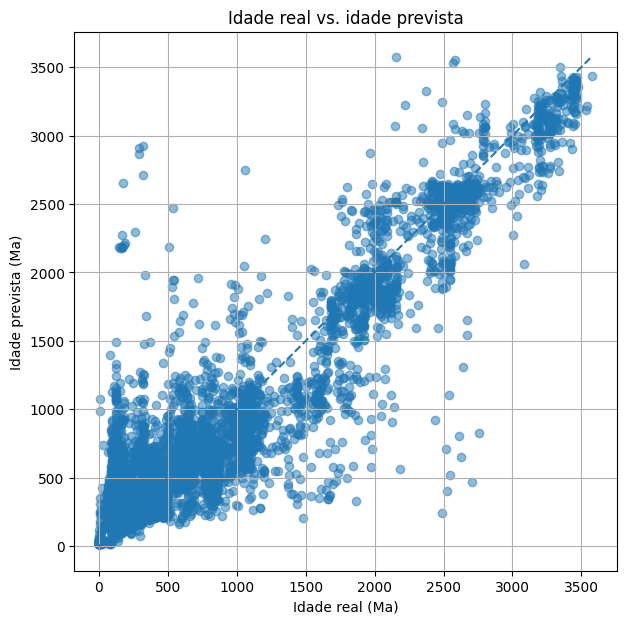

In [148]:
# Idade real vs prevista

plt.figure(figsize=(7, 7))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)

min_age = min(y_test_reg.min(), y_pred_reg.min())
max_age = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_age, max_age], [min_age, max_age], linestyle="--")

plt.xlabel("Idade real (Ma)")
plt.ylabel("Idade prevista (Ma)")
plt.title("Idade real vs. idade prevista")
plt.grid(True)
plt.show()


In [149]:
# Permutation importance da regressao

perm_reg = permutation_importance(
    best_reg_model,
    X_test_reg,
    y_test_reg,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

importance_reg = (
    pd.DataFrame({
        "feature": X_test_reg.columns,
        "importance_mean": perm_reg.importances_mean,
        "importance_std": perm_reg.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_reg.head(20)


,feature,importance_mean,importance_std
0,hf176_hf177,681.874149,13.239503
1,yb176_hf177,27.793236,0.911756
2,hf178_hf177,14.294089,0.694195
3,th_ppm,12.768861,0.694353
4,lu176_hf177,11.665196,0.577130
5,u_ppm,7.509910,0.518032
6,nd_ppm,5.882919,0.348869
7,hf_ppm,2.545508,0.294221
8,y_ppm,2.142870,0.113311
9,lu_ppm,2.129016,0.199176


In [150]:
# Avaliar a regressao como classificador de faixas

y_test_reg_class = y_test_reg.apply(classify_age)
y_pred_reg_class = pd.Series(y_pred_reg, index=y_test_reg.index).apply(classify_age)

print("Accuracy:", accuracy_score(y_test_reg_class, y_pred_reg_class))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_reg_class, y_pred_reg_class))
print("Macro F1:", f1_score(y_test_reg_class, y_pred_reg_class, average="macro"))
print()
print(classification_report(
    y_test_reg_class,
    y_pred_reg_class,
    labels=labels,
    zero_division=0
))


Accuracy: 0.5892273274823611
Balanced Accuracy: 0.5903460936482043
Macro F1: 0.5936986205080361

              precision    recall  f1-score   support

    0-250 Ma       0.81      0.53      0.64      1703
1000-1600 Ma       0.41      0.33      0.37       511
1600-2500 Ma       0.74      0.70      0.72       744
  250-541 Ma       0.46      0.60      0.52      1283
 541-1000 Ma       0.45      0.62      0.52       975
    >2500 Ma       0.84      0.75      0.79       595

    accuracy                           0.59      5811
   macro avg       0.62      0.59      0.59      5811
weighted avg       0.63      0.59      0.60      5811

